P1.PREPROCESS DATA

In [1]:
import torch
import numpy as np
import random

def set_seed(seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
SEED = 42
set_seed(SEED)

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
events=pd.read_csv('E:\Recommnedation Ecommerce\Data\events.csv')
events.head(3)

<>:1: SyntaxWarning: invalid escape sequence '\R'
<>:1: SyntaxWarning: invalid escape sequence '\R'
C:\Users\Admin\AppData\Local\Temp\ipykernel_23908\3052179553.py:1: SyntaxWarning: invalid escape sequence '\R'
  events=pd.read_csv('E:\Recommnedation Ecommerce\Data\events.csv')


,timestamp,visitorid,event,itemid,transactionid
0,1433221332117,257597,view,355908,NaN
1,1433224214164,992329,view,248676,NaN
2,1433221999827,111016,view,318965,NaN


In [6]:
def check_info(events):
  print('The size of events:',events.shape)
  print('The number of itemid unique:', events['itemid'].nunique())
  print('The number of visitorid unique:', events['visitorid'].nunique())
  print(events['event'].value_counts())

In [7]:
check_info(events)

The size of events: (2756101, 5)
The number of itemid unique: 235061
The number of visitorid unique: 1407580
event
view           2664312
addtocart        69332
transaction      22457
Name: count, dtype: int64


In [7]:
print(events.isnull().sum())

timestamp              0
visitorid              0
event                  0
itemid                 0
transactionid    2733644
dtype: int64


In [8]:
events.drop_duplicates(inplace=True)
check_info(events)

The size of events: (2755641, 5)
The number of itemid unique: 235061
The number of visitorid unique: 1407580
event
view           2664218
addtocart        68966
transaction      22457
Name: count, dtype: int64


Explore the type of events

In [9]:
def distribution_of_the_events(events):
  plt.figure(figsize=(8,5))
  eventsCounting=events['event'].value_counts()
  sns.barplot(x=eventsCounting.index,y=eventsCounting.values, color='#c94169')
  plt.title('The ditribution of the event')
  plt.xlabel('Type of event')
  plt.ylabel(f'Number of events')
  plt.show()


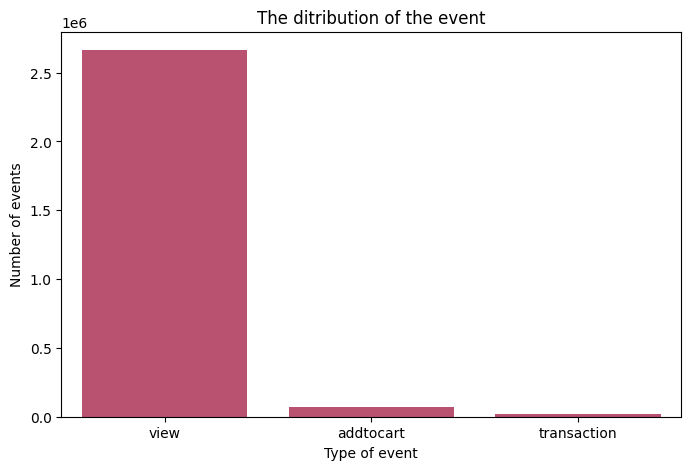

In [10]:
distribution_of_the_events(events)

In [11]:
def Calculate_sparsity_density(events):
    sparsity = 1 - len(events) / (events['visitorid'].nunique() * events['itemid'].nunique())
    density= len(events) / (events['visitorid'].nunique() * events['itemid'].nunique())
    print(f"Sparsity: {sparsity:.4f}")
    print(f"Density: {density:.4f}")
Calculate_sparsity_density(events)

Sparsity: 1.0000
Density: 0.0000


In [12]:
def distribution(events, x):
  if x=='itemid' or x=='visitorid' or x=='property':
    counts = events[x].value_counts()
    plt.figure(figsize=(10, 6))
    plt.hist(counts.values, bins=50, color='pink')
    if x =='itemid':
      plt.xlabel('Event with itemid')
      plt.ylabel('Number of itemid')
      plt.title('Distribution of itemid count by event')
    elif x=='visitorid':
      plt.xlabel('Event with visitorid')
      plt.ylabel('Number of visitorid')
      plt.title('Distribution of visitorid count by event')
    plt.yscale('log')
    plt.show()
  else:
    print('Error')

In [17]:
def top10_low(events, x):
  if x=='itemid' or x=='visitorid':
    counts = events[x].value_counts()
    item_freq_count = counts.value_counts().sort_index()
    top10_low_freq = item_freq_count.head(10)
    plt.figure(figsize=(8, 5))
    bars = plt.bar(top10_low_freq.index.astype(str), top10_low_freq.values, color='#c94169')
    if x =='itemid':
      plt.xlabel('Event with itemid')
      plt.ylabel('Number of itemid')
      plt.title('Top 10 low distribution of itemid count by event')
    else:
      plt.xlabel('Event with visitorid')
      plt.ylabel('Number of visitorid')
      plt.title('Top 10 low distribution of visitorid count by event')
    plt.tight_layout()

    # Hiển thị % trên từng cột (optional)
    total_items = counts.shape[0]
    for i, bar in enumerate(bars):
        pct = 100 * top10_low_freq.values[i] / total_items
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f'{pct:.1f}%', ha='center', va='bottom', fontsize=9)

    plt.show()
  else:
    print('Error')

In [18]:
def statistic(event, x):
  if x=='itemid' or x=='visitorid' :
    counts = event[x].value_counts()
    print(counts.describe())
  else:
    print('Error')

Explore the itemid

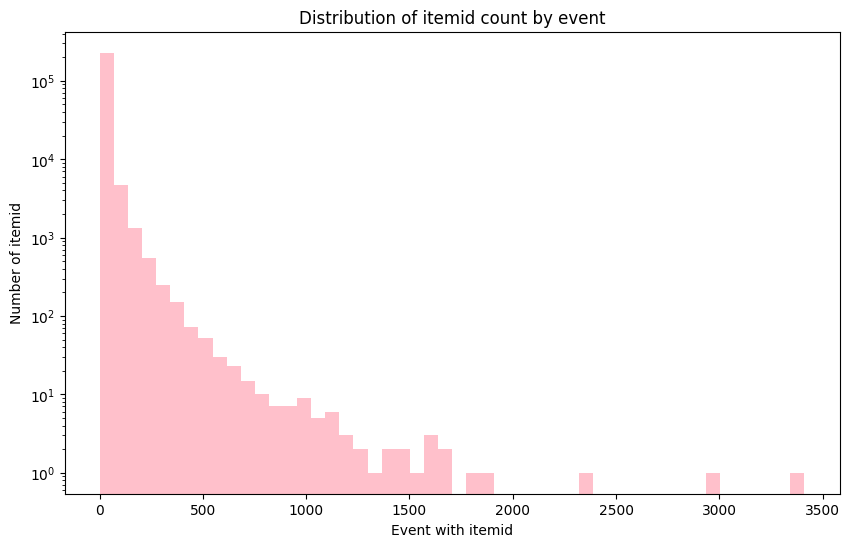

In [19]:
distribution(events,'itemid')

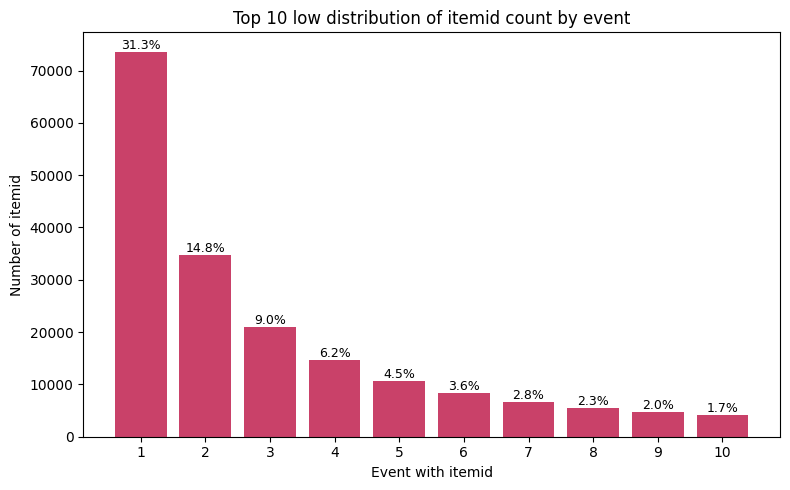

In [20]:
top10_low(events,'itemid')

In [21]:
statistic(events,'itemid')

count    235061.000000
mean         11.723089
std          37.024810
min           1.000000
25%           1.000000
50%           3.000000
75%           9.000000
max        3412.000000
Name: count, dtype: float64


Explore user

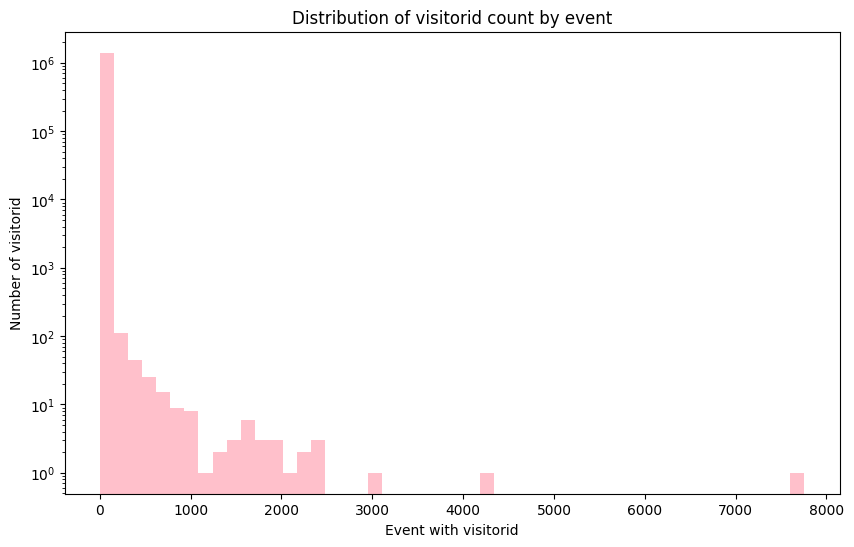

In [22]:
distribution(events,'visitorid')

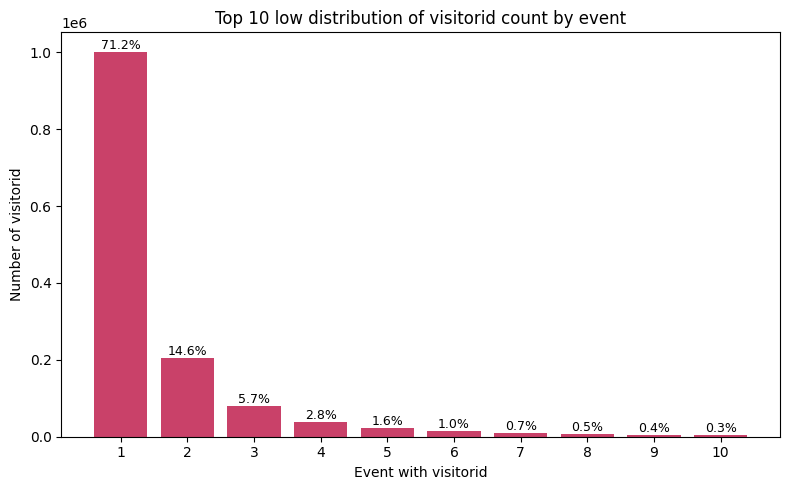

In [23]:
top10_low(events,'visitorid')

In [24]:
statistic(events,'visitorid')

count    1.407580e+06
mean     1.957715e+00
std      1.257981e+01
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      2.000000e+00
max      7.757000e+03
Name: count, dtype: float64


Filter data

In [25]:
# Giữ lại toàn bộ addtocart và transaction
addtocarts = events[events['event'] == 'addtocart']
transactions = events[events['event'] == 'transaction']
# Lấy 10% các event "view" (hoặc nhiều hơn nếu máy đủ mạnh)
views = events[events['event'] == 'view'].sample(frac=0.1, random_state=42)
final_events = pd.concat([views, addtocarts, transactions]).reset_index(drop=True)
check_info(final_events)
print ( " \ nPercentage of events : " )
print ( final_events['event'].value_counts( normalize = True ) * 100)

<>:8: SyntaxWarning: invalid escape sequence '\ '
<>:8: SyntaxWarning: invalid escape sequence '\ '
C:\Users\Admin\AppData\Local\Temp\ipykernel_10116\1374217726.py:8: SyntaxWarning: invalid escape sequence '\ '
  print ( " \ nPercentage of events : " )


The size of events: (357845, 5)
The number of itemid unique: 94202
The number of visitorid unique: 242807
event
view           266422
addtocart       68966
transaction     22457
Name: count, dtype: int64
 \ nPercentage of events : 
event
view           74.451788
addtocart      19.272590
transaction     6.275622
Name: proportion, dtype: float64


In [28]:
from typing_extensions import final
def filter_k_core(data, k_user, k_item):
    print("Start Filtering K-Core...")
    while True:
        # Đếm số lượng tương tác của mỗi user và item
        user_counts = data['visitorid'].value_counts()
        item_counts = data['itemid'].value_counts()
        # Tìm user và item không đủ k tương tác
        weak_users = user_counts[user_counts < k_user].index
        weak_items = item_counts[item_counts < k_item].index
        # Ghi lại số lượng bị loại bỏ
        initial_rows = len(data)
        users_before = data['visitorid'].nunique()
        items_before = data['itemid'].nunique()
        # Loại bỏ user và item yếu
        data = data[~data['visitorid'].isin(weak_users)]
        data = data[~data['itemid'].isin(weak_items)]
        # Nếu không có gì thay đổi thì dừng vòng lặp
        if len(weak_users) == 0 and len(weak_items) == 0:
            print("Finish filtering K-Core.")
            break
        print(f"Remove {users_before - data['visitorid'].nunique()} users, {items_before - data['itemid'].nunique()} items, {initial_rows - len(data)} rows.")

    return data

print("\nThe size of dataset before filtering:")
check_info(final_events)
user_counts = final_events['visitorid'].value_counts()
itemid_counts = final_events['itemid'].value_counts()
filtered_events = filter_k_core(final_events.copy(), k_user= 2, k_item=itemid_counts.mean())
print("The size of dataset after filtering:")
check_info(filtered_events)


The size of dataset before filtering:
The size of events: (357845, 5)
The number of itemid unique: 94202
The number of visitorid unique: 242807
event
view           266422
addtocart       68966
transaction     22457
Name: count, dtype: int64
Start Filtering K-Core...
Remove 206127 users, 74005 items, 231296 rows.
Remove 7343 users, 8431 items, 20591 rows.
Remove 3077 users, 534 items, 4338 rows.
Remove 443 users, 404 items, 1434 rows.
Remove 236 users, 45 items, 355 rows.
Remove 38 users, 35 items, 129 rows.
Remove 15 users, 2 items, 20 rows.
Remove 3 users, 3 items, 10 rows.
Remove 1 users, 0 items, 1 rows.
Finish filtering K-Core.
The size of dataset after filtering:
The size of events: (99671, 5)
The number of itemid unique: 10743
The number of visitorid unique: 25524
event
view           43075
addtocart      38865
transaction    17731
Name: count, dtype: int64


The data after filtering

The distribution of events after filtering:


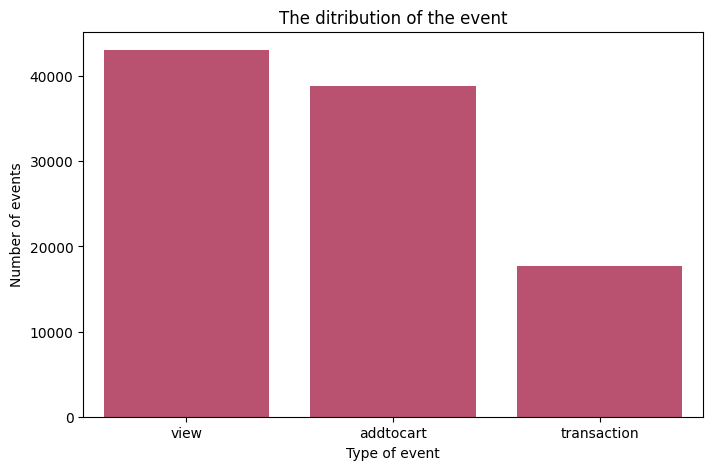

In [29]:
print('The distribution of events after filtering:')
distribution_of_the_events(filtered_events)

The distribution of itemid after filtering:


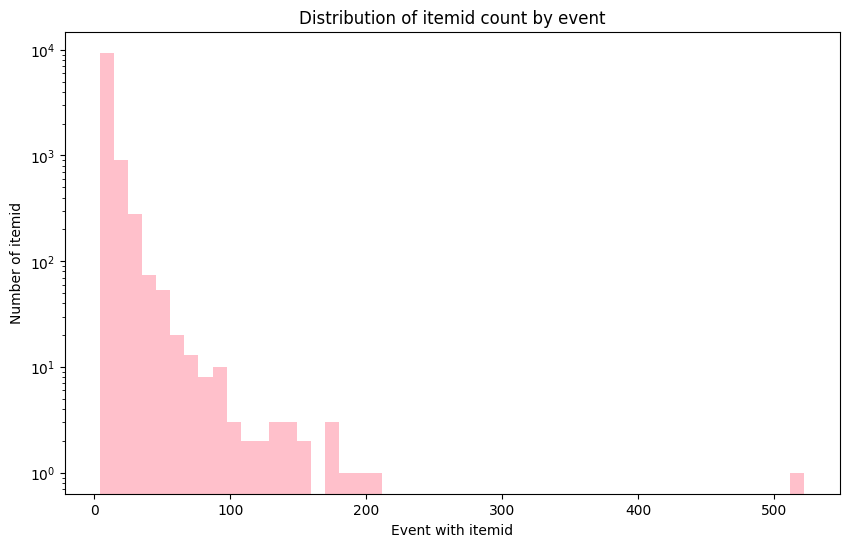

Top 10 low distribution of itemid after filtering:


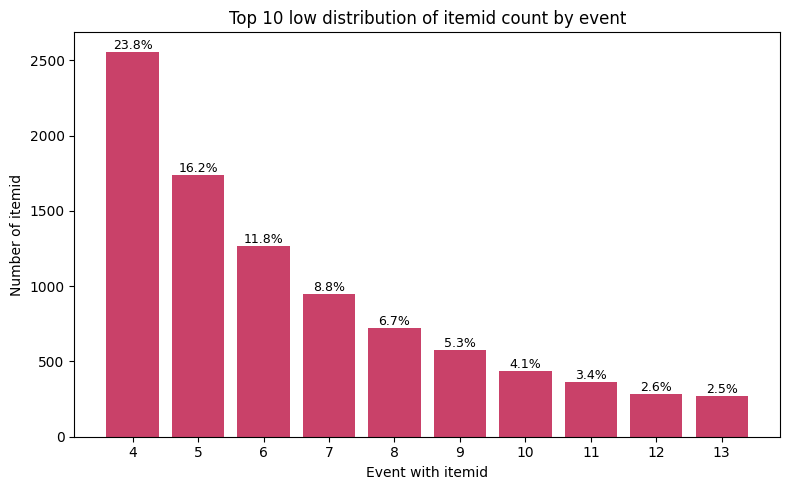

The distribution of visitorid after filtering:


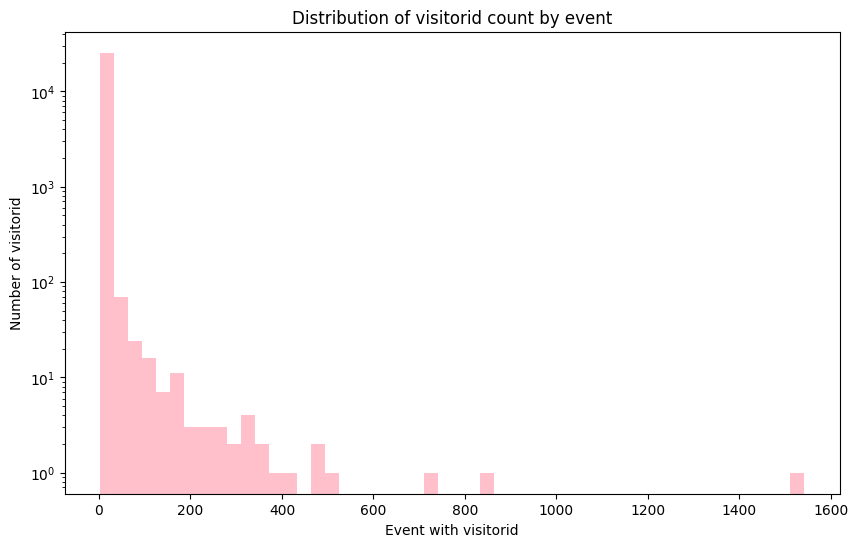

Top 10 low distribution of visitorid after filtering:


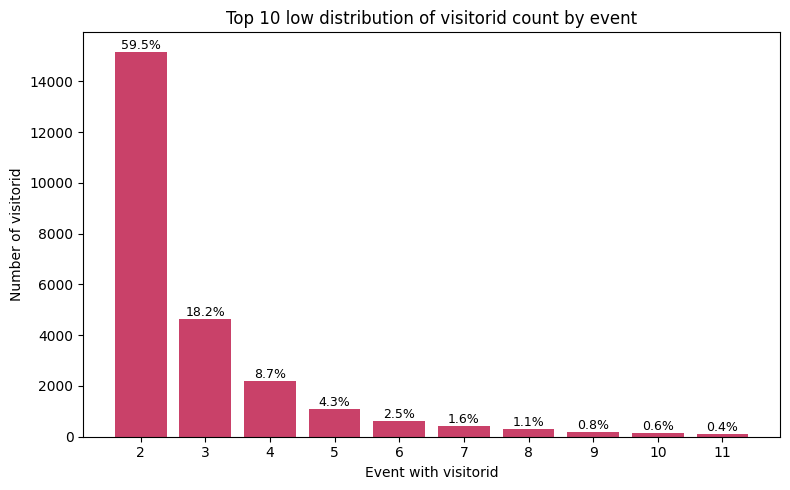

In [30]:
print('The distribution of itemid after filtering:')
distribution(filtered_events,'itemid')
print('Top 10 low distribution of itemid after filtering:')
top10_low(filtered_events,'itemid')
print('The distribution of visitorid after filtering:')
distribution(filtered_events,'visitorid')
print('Top 10 low distribution of visitorid after filtering:')
top10_low(filtered_events,'visitorid')

CÁCH 2: MERGE VỚI FEATURE CATEGORY



P2.MERGE FEATURE

In [31]:
filtered_events.head(3)

,timestamp,visitorid,event,itemid,transactionid
1,1435612368758,1172121,view,374941,NaN
11,1436187122375,660953,view,172959,NaN
15,1440127231048,1025012,view,251594,NaN


In [32]:
check_info(filtered_events)

The size of events: (99671, 5)
The number of itemid unique: 10743
The number of visitorid unique: 25524
event
view           43075
addtocart      38865
transaction    17731
Name: count, dtype: int64


In [44]:
def check_info_prop(data):
  print('The size of the dataset:', data.shape)
  print('The itemid unique:', data['itemid'].nunique())
  print('The property unique:', data['property'].nunique())
  print(data['property'].value_counts())

In [34]:
def top10_high(data,x):
  if x=='property':
    counts = data[x].value_counts()
    top10_high_counts = counts.head(10)
    plt.figure(figsize=(10, 6))
    bars = plt.bar(top10_high_counts.index.astype(str), top10_high_counts.values, color='#c94169')
    plt.xlabel('Property ID')
    plt.ylabel('Number of Occurrences')
    plt.title('Top 10 Most Frequent Properties')
    plt.xticks(rotation=90)
    plt.tight_layout()


    for x in bars:
        yval = x.get_height()
        plt.text(x.get_x() + x.get_width()/2, yval, round(yval, 2), va='bottom', ha='center') # Display value above bar

    plt.show()
  else:
    print('Error: This function is designed for property data.')

Preprocess data item_properties

In [35]:
props1 = pd.read_csv('item_properties_part1.csv')
props2 = pd.read_csv('item_properties_part2.csv')

In [36]:
props1.head(3)

,timestamp,itemid,property,value
0,1435460400000,460429,categoryid,1338
1,1441508400000,206783,888,1116713 960601 n277.200
2,1439089200000,395014,400,n552.000 639502 n720.000 424566


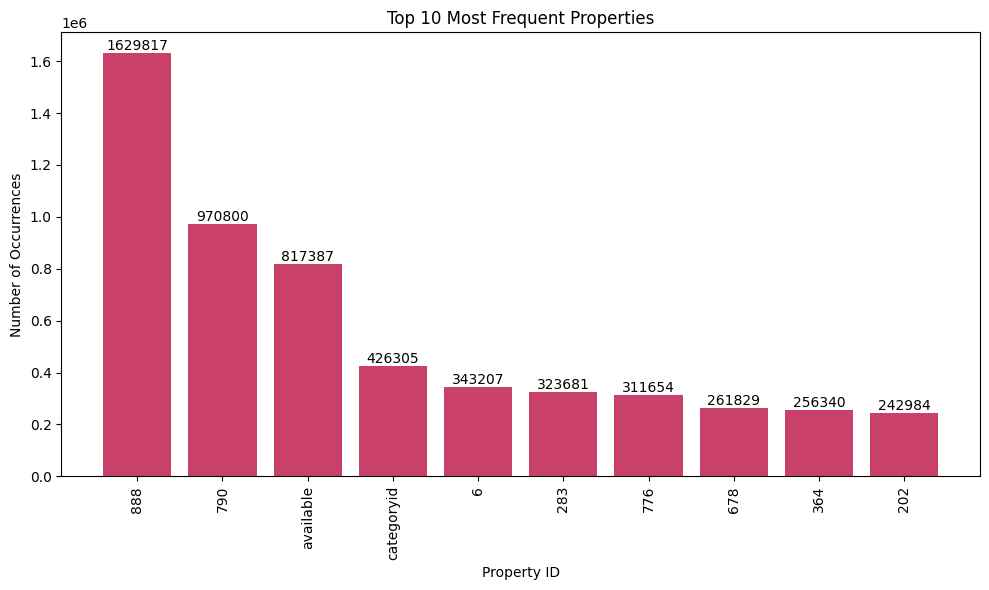

In [37]:
top10_high(props1,'property')

In [38]:
check_info_prop(props1)

The size of the dataset: (10999999, 4)
The itemid unique: 417053
The property unique: 1097
property
888           1629817
790            970800
available      817387
categoryid     426305
6              343207
               ...   
598                 1
244                 1
424                 1
494                 1
712                 1
Name: count, Length: 1097, dtype: int64


In [39]:
check_info_prop(props2)

The size of the dataset: (9275903, 4)
The itemid unique: 417053
The property unique: 1094
property
888           1370581
790            819716
available      686252
categoryid     361909
6              288264
               ...   
494                 1
57                  1
1091                1
522                 1
769                 1
Name: count, Length: 1094, dtype: int64


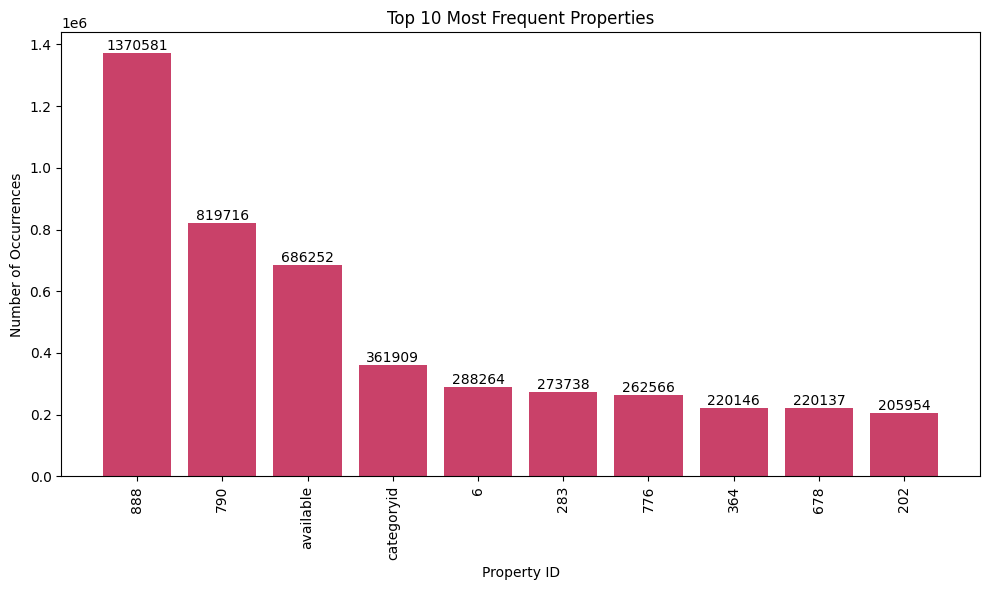

In [40]:
top10_high(props2,'property')

In [41]:
# Kiểm tra xem coi là mỗi itemid có property là categoryid thì có bao nhiêu giá trị categoryid
category_properties = props1[props1['property'] == 'categoryid']
# Group by 'itemid' and count the number of unique 'value' (categoryid)
categoryid_counts_per_item = category_properties.groupby('itemid')['value'].nunique()
distribution = categoryid_counts_per_item.value_counts()
print(distribution)

value
1    215074
2     13174
3      1066
4        27
Name: count, dtype: int64


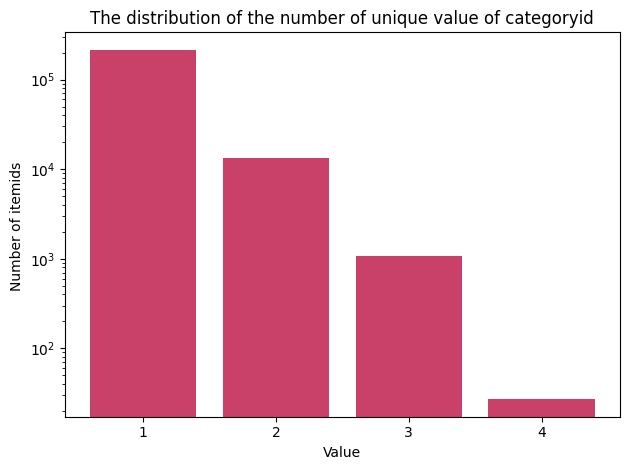

In [43]:
bars = plt.bar(distribution.index.astype(str), distribution.values, color='#c94169')
plt.xlabel('Value')
plt.ylabel('Number of itemids ')
plt.title('The distribution of the number of unique value of categoryid')
plt.yscale('log')
plt.tight_layout()

In [45]:
from sklearn.preprocessing import LabelEncoder
print("Start processing item properties...")
item_props = pd.concat([props1, props2], ignore_index=True)
print("Finish reading và joining 2 file properties.")

# Lọc các dòng có property là 'categoryid' và lấy category mới nhất
if not item_props.empty:
    cat_df = item_props[item_props['property'] == 'categoryid'].copy()
    latest_cat_df = cat_df.sort_values('timestamp').drop_duplicates('itemid', keep='last')
    latest_cat_df = latest_cat_df[['itemid', 'value']].rename(columns={'value': 'categoryid'})
    # Ghép thông tin category vào final_events
    final_events_with_cat = pd.merge(filtered_events, latest_cat_df, on='itemid', how='left')
else:
    # Nếu không có file properties, tạo cột category rỗng
    final_events_with_cat = filtered_events.copy()
    final_events_with_cat['categoryid'] = -1
print("The number of null values: ", final_events_with_cat['categoryid'].isnull().sum())
# Xử lý các item không có category
final_events_with_cat['categoryid'].fillna(-1, inplace=True)
print("Finish joining.")








Start processing item properties...
Finish reading và joining 2 file properties.
The number of null values:  1981
Finish joining.


C:\Users\Admin\AppData\Local\Temp\ipykernel_10116\1650716418.py:19: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  final_events_with_cat['categoryid'].fillna(-1, inplace=True)


P3.Implemment LightGCN and evaluate

In [47]:
final_events_with_cat.head(3)

,timestamp,visitorid,event,itemid,transactionid,categoryid
0,1435612368758,1172121,view,374941,NaN,1135
1,1436187122375,660953,view,172959,NaN,1051
2,1440127231048,1025012,view,251594,NaN,1233


In [48]:
# Gán trọng số cho từng loại event
event_weight = {
    'view': 1.0,
    'addtocart': 3.0,
    'transaction': 5.0
}

# Sử dụng dataframe đã có category
interactions = final_events_with_cat[['visitorid', 'itemid', 'event', 'timestamp','categoryid']]
interactions = interactions.drop_duplicates(subset=['visitorid', 'itemid', 'event'])
interactions['weight'] = interactions['event'].map(event_weight)

# Tạo các encoder
user_encoder = LabelEncoder()
item_encoder = LabelEncoder()
category_encoder = LabelEncoder() # Thêm encoder cho category



In [49]:
# Tạo các cột index
interactions['user'] = user_encoder.fit_transform(interactions['visitorid'])
interactions['item'] = item_encoder.fit_transform(interactions['itemid'])
interactions['categoryid'] = interactions['categoryid'].astype(str)
interactions['category_idx'] = category_encoder.fit_transform(interactions['categoryid'])

# Lấy số lượng thực thể
num_users = interactions['user'].nunique()
num_items = interactions['item'].nunique()
num_categories = interactions['category_idx'].nunique()

print(f"\nSố lượng user: {num_users}")
print(f"Số lượng item: {num_items}")
print(f"Số lượng category: {num_categories}")


Số lượng user: 25524
Số lượng item: 10743
Số lượng category: 665


In [50]:
# Lọc theo người dùng , timestamp
interactions = interactions.sort_values(['user', 'timestamp'])
print("Start splitting with special handling for users with 1 event...")
user_event_counts = interactions['user'].value_counts()

users_with_1_event = user_event_counts[user_event_counts == 1].index
users_with_2_events = user_event_counts[user_event_counts == 2].index
users_with_3plus_events = user_event_counts[user_event_counts >= 3].index

print(f"Users with 1 event: {len(users_with_1_event)}")
print(f"Users with 2 events: {len(users_with_2_events)}")
print(f"Users with 3+ events: {len(users_with_3plus_events)}")

# TEST
# Test : những user >=2 event
if len(users_with_2_events) + len(users_with_3plus_events) > 0:
    test_idx = interactions[interactions['user'].isin(user_event_counts[user_event_counts >= 2].index)].groupby('user').tail(1).index
    test_interactions = interactions.loc[test_idx]
else:
    test_interactions = pd.DataFrame(columns=interactions.columns)
    test_idx = pd.Index([])

remaining_after_test = interactions.drop(test_idx)

# VALIDATION
# Người dùng với >=2 event sau khi dã trừ đi tệp test
remaining_user_counts = remaining_after_test['user'].value_counts()
users_for_val = remaining_user_counts[remaining_user_counts >= 2].index

if len(users_for_val) > 0:
    val_idx = remaining_after_test[remaining_after_test['user'].isin(users_for_val)].groupby('user').tail(1).index
    val_interactions = remaining_after_test.loc[val_idx]
else:
    val_interactions = pd.DataFrame(columns=interactions.columns)
    val_idx = pd.Index([])

# TRAIN
# Tất cả dữ liệu còn lại => train
train_interactions = remaining_after_test.drop(val_idx)

print(f"\nData split results:")
print(f"Train: {len(train_interactions)} interactions, {train_interactions['user'].nunique()} users")
print(f"Validation: {len(val_interactions)} interactions, {val_interactions['user'].nunique()} users")
print(f"Test: {len(test_interactions)} interactions, {test_interactions['user'].nunique()} users")

# Users with 1 event will only appear in train
users_1_event_in_train = set(users_with_1_event) & set(train_interactions['user'].unique())
print(f"Users with 1 event in train: {len(users_1_event_in_train)}")

Start splitting with special handling for users with 1 event...
Users with 1 event: 3530
Users with 2 events: 14019
Users with 3+ events: 7975

Data split results:
Train: 54484 interactions, 25524 users
Validation: 7975 interactions, 7975 users
Test: 21994 interactions, 21994 users
Users with 1 event in train: 3530


In [57]:
# Tính toán và in ra tỷ lệ phần trăm
total_interactions_before_split = len(interactions)
train_percentage = (len(train_interactions) / total_interactions_before_split) * 100
val_percentage = (len(val_interactions) / total_interactions_before_split) * 100
test_percentage = (len(test_interactions) / total_interactions_before_split) * 100

print(f"\nPhân bổ dữ liệu so với bộ dữ liệu trước khi chia:")
print(f"- Train: {len(train_interactions)} tương tác, chiếm {train_percentage:.2f}%")
print(f"- Validation: {len(val_interactions)} tương tác, chiếm {val_percentage:.2f}%")
print(f"- Test: {len(test_interactions)} tương tác, chiếm {test_percentage:.2f}%")


Phân bổ dữ liệu so với bộ dữ liệu trước khi chia:
- Train: 54484 tương tác, chiếm 64.51%
- Validation: 7975 tương tác, chiếm 9.44%
- Test: 21994 tương tác, chiếm 26.04%


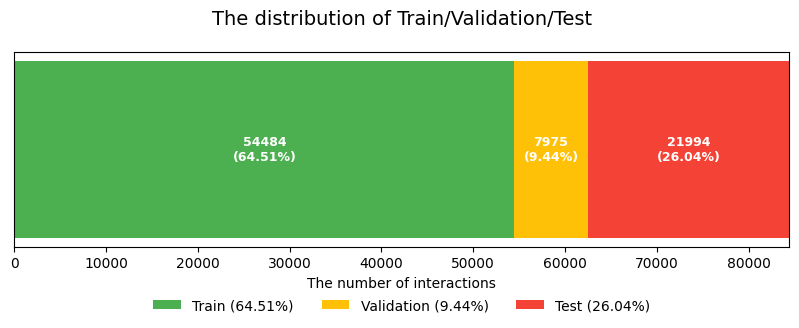

In [ ]:

labels = ['Train', 'Validation', 'Test']
sizes = [len(train_interactions), len(val_interactions), len(test_interactions)]
total = sum(sizes)
percentages = [s/total*100 for s in sizes]
colors = ['#4CAF50', '#FFC107', '#F44336']

fig, ax = plt.subplots(figsize=(10, 2.5))

# Vẽ thanh ngang chồng
left = 0
for i, (size, label, color) in enumerate(zip(sizes, labels, colors)):
    ax.barh('Tương tác', size, left=left, label=f'{label} ({percentages[i]:.2f}%)', color=color, height=0.5)
    
    # Thêm văn bản (số lượng và phần trăm)
    text_x = left + size / 2
    ax.text(text_x, 0, f'{size}\n({percentages[i]:.2f}%)', ha='center', va='center', color='white', fontweight='bold', fontsize=9)
    
    left += size

# Tùy chỉnh biểu đồ
ax.set_title('The distribution of Train/Validation/Test', pad=20, fontsize=14)
ax.set_xlim(0, total)
ax.set_xlabel('The number of interactions')
ax.set_yticks([]) # Ẩn trục y vì chỉ có một thanh
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2), ncol=3, frameon=False)

# Điều chỉnh khoảng trống dưới cùng để tránh chồng chéo
plt.subplots_adjust(bottom=0.1)
plt.show()

In [ ]:
# Tạo edge_index và edge_weight cho graph TỪ TẬP TRAIN CUỐI CÙNG
user_indices = torch.tensor(train_interactions['user'].values, dtype=torch.long)
item_indices = torch.tensor(train_interactions['item'].values, dtype=torch.long)
edge_weight = torch.tensor(train_interactions['weight'].values, dtype=torch.float)

edge_index = torch.stack([user_indices, item_indices], dim=0)

# Tạo itemid2cat_tensor (ánh xạ từ item_idx -> category_idx)
# Sắp xếp theo 'item' để đảm bảo thứ tự index, sau đó lấy giá trị category
item_to_cat_map_df = interactions[['item', 'category_idx']].drop_duplicates('item').sort_values('item')
itemid2cat_tensor = torch.tensor(item_to_cat_map_df['category_idx'].values, dtype=torch.long)

# Chuyển tensors sang device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
edge_index = edge_index.to(device)
edge_weight = edge_weight.to(device)
itemid2cat_tensor = itemid2cat_tensor.to(device)

print("\nTạo Tensors thành công.")
print("Edge index shape:", edge_index.shape)
print("Item-to-Category tensor shape:", itemid2cat_tensor.shape)


Tạo Tensors thành công.
Edge index shape: torch.Size([2, 54484])
Item-to-Category tensor shape: torch.Size([10743])


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class LightGCN_with_Category(nn.Module):
    def __init__(self, num_users, num_items, num_categories, embedding_dim=128, n_layers=2):
        super().__init__()
        self.num_users = num_users
        self.num_items = num_items
        self.embedding_dim = embedding_dim
        self.n_layers = n_layers

        self.embedding = nn.Embedding(num_users + num_items, embedding_dim)
        self.category_embedding = nn.Embedding(num_categories, embedding_dim)
        self.alpha = nn.Parameter(torch.ones(self.n_layers + 1) / (self.n_layers + 1))

        self.reset_parameters()

    def reset_parameters(self):
        nn.init.xavier_uniform_(self.embedding.weight)
        nn.init.xavier_uniform_(self.category_embedding.weight)

    def propagate(self, edge_index, edge_norm, embeddings):
        row, col = edge_index
        agg = torch.zeros_like(embeddings)
        agg.index_add_(0, row, embeddings[col] * edge_norm.unsqueeze(1))
        return agg

    def get_embedding(self, edge_index, edge_weight, itemid2cat_tensor):
        all_initial_embeddings = self.embedding.weight.clone()
        cat_embeds = self.category_embedding(itemid2cat_tensor)
        all_initial_embeddings[self.num_users:] += cat_embeds

        row, col = edge_index
        item_indices_shifted = col + self.num_users
        full_edge_index = torch.cat([torch.stack([row, item_indices_shifted]), torch.stack([item_indices_shifted, row])], dim=1)

        full_row, full_col = full_edge_index
        deg = torch.bincount(full_row, minlength=self.num_users + self.num_items).float()
        deg_inv_sqrt = deg.pow(-0.5)
        deg_inv_sqrt[deg_inv_sqrt == float('inf')] = 0
        edge_norm = deg_inv_sqrt[full_row] * deg_inv_sqrt[full_col]

        if edge_weight is not None:
            full_edge_weight = torch.cat([edge_weight, edge_weight])
            edge_norm = edge_norm * full_edge_weight

        embeddings_list = [all_initial_embeddings]
        current_embeddings = all_initial_embeddings
        for _ in range(self.n_layers):
            current_embeddings = self.propagate(full_edge_index, edge_norm, current_embeddings)
            embeddings_list.append(current_embeddings)

        stacked_embeddings = torch.stack(embeddings_list, dim=1)
        layer_weights = F.softmax(self.alpha, dim=0)
        final_embeddings = (stacked_embeddings * layer_weights[None, :, None]).sum(dim=1)
        users_emb, items_emb = torch.split(final_embeddings, [self.num_users, self.num_items])
        return users_emb, items_emb

    def forward(self, edge_index, edge_weight, itemid2cat_tensor):
        """
        Hàm forward chuẩn, chỉ trả về embeddings.
        """
        return self.get_embedding(edge_index, edge_weight, itemid2cat_tensor)

In [ ]:
def bpr_loss_reg(user_emb, pos_emb, neg_emb, reg_weight=1e-4):
    pos_scores = (user_emb * pos_emb).sum(dim=1)
    neg_scores = (user_emb * neg_emb).sum(dim=1)
    bpr = -torch.log(torch.sigmoid(pos_scores - neg_scores) + 1e-8).mean()
    reg = (user_emb.norm(2).pow(2) + pos_emb.norm(2).pow(2) + neg_emb.norm(2).pow(2)) / user_emb.size(0) / 3
    return bpr + reg_weight * reg

In [ ]:
def evaluate_lightgcn(model, train_interactions, test_interactions, edge_index, edge_weight, itemid2cat_tensor, K=20, context="Test"):
    """
    Hàm đánh giá model LightGCN.
    """
    model.eval()
    with torch.no_grad():
        user_emb, item_emb = model.get_embedding(edge_index, edge_weight, itemid2cat_tensor)

    user_emb = user_emb.cpu().numpy()
    item_emb = item_emb.cpu().numpy()

    hits, ndcgs = [], []

    user2train_items = train_interactions.groupby('user')['item'].apply(set).to_dict()
    user2test_item = test_interactions.set_index('user')['item'].to_dict()
    test_users = test_interactions['user'].unique()

    for user_idx in test_users:
        test_item_idx = user2test_item.get(user_idx)
        if test_item_idx is None: continue

        train_items = user2train_items.get(user_idx, set())

        scores = user_emb[user_idx] @ item_emb.T
        scores[list(train_items)] = -np.inf

        top_k_indices = np.argpartition(scores, -K)[-K:]
        top_k_indices = top_k_indices[np.argsort(-scores[top_k_indices])]

        if test_item_idx in top_k_indices:
            hits.append(1)
            rank = np.where(top_k_indices == test_item_idx)[0][0] + 1
            ndcgs.append(1 / np.log2(rank + 1))
        else:
            hits.append(0)
            ndcgs.append(0)

    hr = np.mean(hits) if hits else 0
    ndcg = np.mean(ndcgs) if ndcgs else 0

    print(f"[{context}] HR@{K}: {hr:.4f}, NDCG@{K}: {ndcg:.4f}")
    return hr, ndcg

In [ ]:
# Chuẩn bị dữ liệu sampling
unique_users_in_train = train_interactions['user'].unique()
user_pos_items_dict = train_interactions.groupby('user')['item'].apply(set).to_dict()
item_counts = train_interactions['item'].value_counts()
full_item_counts = item_counts.reindex(np.arange(num_items), fill_value=1)
sampling_probs = np.power(full_item_counts.values, 0.75)
sampling_probs /= np.sum(sampling_probs)
item_indices_for_sampling = full_item_counts.index.values
print("Hoàn tất.")

def sample_batch_popularity(batch_size, users_to_sample, pos_dict, pop_item_indices, pop_item_probs):
    users = np.random.choice(users_to_sample, size=batch_size, replace=True)
    pos_items, neg_items = [], []
    for u in users:
        user_pos_set = pos_dict.get(u, set())
        if not user_pos_set: pos_items.append(np.random.randint(0, num_items)); neg_items.append(np.random.randint(0, num_items)); continue
        pos_item = np.random.choice(list(user_pos_set)); pos_items.append(pos_item)
        while True:
            neg_item = np.random.choice(pop_item_indices, p=pop_item_probs)
            if neg_item not in user_pos_set: neg_items.append(neg_item); break
    return torch.LongTensor(users), torch.LongTensor(pos_items), torch.LongTensor(neg_items)

Hoàn tất.


In [ ]:
import torch.optim as optim
import numpy as np
import copy
import pandas as pd

# THỬ NGHIỆM SO SÁNH CÔNG BẰNG CÁC KIẾN TRÚC MODEL (VỚI LỊCH SỬ ĐỂ VẼ ĐỒ THỊ)
architectures_to_test = [2, 3]
K = 20
embedding_dim = 256
reg_weight = 1e-4
lr = 0.0005
batch_size = 1024

results = {}
best_overall_model_state = None
winning_architecture_hr = -1

# TỰ ĐỘNG LƯU DỮ LIỆU ĐỂ VẼ ĐỒ THỊ
training_history = {}

print("Start experiment...\n")

for n_layers in architectures_to_test:
    print(f"=============== TESTING ARCHITECTURE: n_layers = {n_layers} ===============")

    # Khởi tạo lưu trữ cho kiến trúc này
    training_history[n_layers] = {
        'epochs': [],
        'losses': [],
        'hr_scores': [],
        'ndcg_scores': []
    }

    model = LightGCN_with_Category(num_users, num_items, num_categories, embedding_dim, n_layers).to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    patience, wait, best_hr_for_this_arch, best_epoch_for_this_arch, best_model_state_for_this_arch = 8, 0, 0, 0, None
    epochs = 28
    num_batches_per_epoch = len(train_interactions) // batch_size if len(train_interactions) > 0 else 1

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for _ in range(num_batches_per_epoch):
            users, pos_items, neg_items = sample_batch_popularity(batch_size, unique_users_in_train, user_pos_items_dict, item_indices_for_sampling, sampling_probs)
            users, pos_items, neg_items = users.to(device), pos_items.to(device), neg_items.to(device)

            # GỌI MODEL VÀ TÍNH LOSS
            user_emb, item_emb = model(edge_index, edge_weight, itemid2cat_tensor)
            u_emb, pos_emb, neg_emb = user_emb[users], item_emb[pos_items], item_emb[neg_items]

            optimizer.zero_grad()
            loss = bpr_loss_reg(u_emb, pos_emb, neg_emb, reg_weight)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        avg_loss = total_loss / num_batches_per_epoch if num_batches_per_epoch > 0 else 0
        print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}", end=" | ")
        hr, ndcg = evaluate_lightgcn(model, train_interactions, val_interactions, edge_index, edge_weight, itemid2cat_tensor, K=K, context="Validation")

        # LƯU DỮ LIỆU VÀO LỊCH SỬ
        training_history[n_layers]['epochs'].append(epoch + 1)
        training_history[n_layers]['losses'].append(avg_loss)
        training_history[n_layers]['hr_scores'].append(hr)
        training_history[n_layers]['ndcg_scores'].append(ndcg)

        if hr > best_hr_for_this_arch:
            best_hr_for_this_arch = hr; best_epoch_for_this_arch = epoch + 1; wait = 0
            best_model_state_for_this_arch = copy.deepcopy(model.state_dict())
            print(f"--> Validation HR improves: {best_hr_for_this_arch:.4f}.")
        else:
            wait += 1
            if wait >= patience: print(f"--> EARLY STOPPING!"); break

    results[n_layers] = (best_hr_for_this_arch, best_epoch_for_this_arch)
    print(f"The best result for n_layers = {n_layers}: HR@{K} = {best_hr_for_this_arch:.4f} tại epoch {best_epoch_for_this_arch}\n")
    if best_hr_for_this_arch > winning_architecture_hr:
        winning_architecture_hr = best_hr_for_this_arch
        best_overall_model_state = best_model_state_for_this_arch

print("\n\n=============== Final ===============")
for n_layers, (hr, epoch) in results.items():
    print(f"Architecture n_layers={n_layers}: Best Validation HR@{K} = {hr:.4f} (tại epoch {epoch})")

best_n_layers = max(results, key=lambda k: results[k][0])
best_hr, best_epoch = results[best_n_layers]
print(f"\n The WINNER n_layers = {best_n_layers} với HR@{K} = {best_hr:.4f} on validation data.")
print(f"  Epoch is: {best_epoch}")

# =============== LOAD LẠI MODEL TỐT NHẤT VÀ ĐÁNH GIÁ TRÊN TEST ===============
print("\n=============== FINAL TEST EVALUATION ===============")
print(f"Loading best model: {best_n_layers} layers at epoch {best_epoch}...")

# Khởi tạo model với kiến trúc tốt nhất
final_model = LightGCN_with_Category(num_users, num_items, num_categories, embedding_dim, best_n_layers).to(device)



Start experiment...

=============== TESTING ARCHITECTURE: n_layers = 2 ===============
Epoch 1/28, Loss: 0.4765 | [Validation] HR@20: 0.1058, NDCG@20: 0.0420
--> Validation HR improves: 0.1058.
Epoch 2/28, Loss: 0.3075 | [Validation] HR@20: 0.1076, NDCG@20: 0.0441
--> Validation HR improves: 0.1076.
Epoch 3/28, Loss: 0.2127 | [Validation] HR@20: 0.1107, NDCG@20: 0.0451
--> Validation HR improves: 0.1107.
Epoch 4/28, Loss: 0.1575 | [Validation] HR@20: 0.1127, NDCG@20: 0.0455
--> Validation HR improves: 0.1127.
Epoch 5/28, Loss: 0.1236 | [Validation] HR@20: 0.1111, NDCG@20: 0.0451
Epoch 6/28, Loss: 0.1024 | [Validation] HR@20: 0.1124, NDCG@20: 0.0453
Epoch 7/28, Loss: 0.0852 | [Validation] HR@20: 0.1118, NDCG@20: 0.0452
Epoch 8/28, Loss: 0.0736 | [Validation] HR@20: 0.1126, NDCG@20: 0.0450
Epoch 9/28, Loss: 0.0627 | [Validation] HR@20: 0.1124, NDCG@20: 0.0450
Epoch 10/28, Loss: 0.0567 | [Validation] HR@20: 0.1131, NDCG@20: 0.0451
--> Validation HR improves: 0.1131.
Epoch 11/28, Loss: 0.

In [ ]:
if best_overall_model_state:
    final_model.load_state_dict(best_overall_model_state)
    print(f"Loaded model state!")

    print("\nEvaluating on test set...")
    test_hr, test_ndcg = evaluate_lightgcn(final_model, train_interactions, test_interactions,
                                          edge_index, edge_weight, itemid2cat_tensor, K=K, context="Test")


    print(f"HR@{K}: {test_hr:.4f}")
    print(f"NDCG@{K}: {test_ndcg:.4f}")

    # Gán cho biến global để các cell khác có thể dùng
    model = final_model

else:
    print("Error")

Loaded model state!

Evaluating on test set...
[Test] HR@20: 0.1201, NDCG@20: 0.0516
HR@20: 0.1201
NDCG@20: 0.0516


2 layers: Best HR=0.1165 (epoch 26)
3 layers: Best HR=0.1228 (epoch 4)


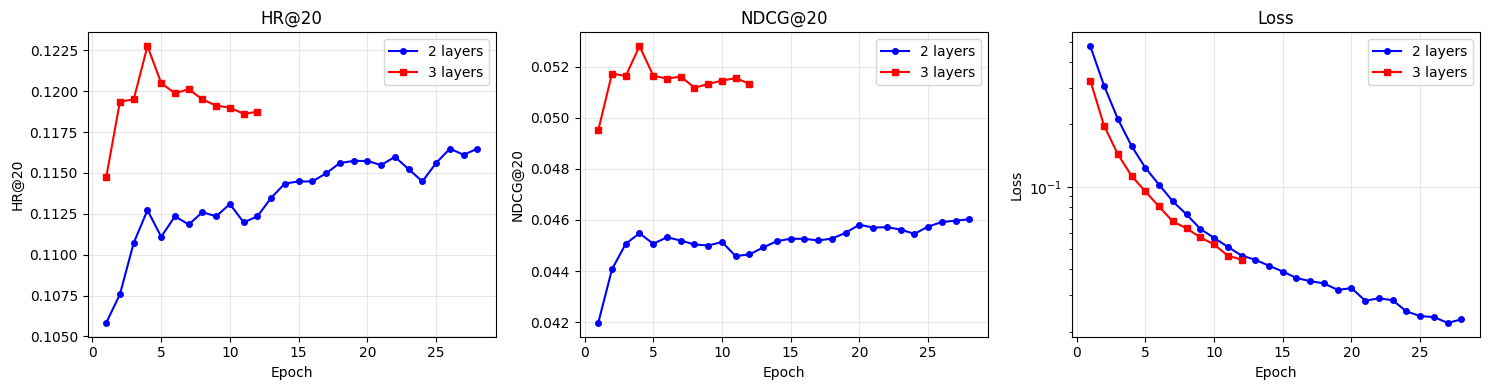


 Winner: 3 layers với HR@20=0.1228


In [ ]:
# VẼ ĐỒ THỊ TRAINING PROGRESS

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 4))
colors = ['blue', 'red', 'green', 'orange']
markers = ['o', 's', '^', 'D']

best_hr_overall = 0
best_arch = None

for i, (n_layers, data) in enumerate(training_history.items()):
    color = colors[i]
    marker = markers[i]
    epochs, hr, ndcg, loss = data['epochs'], data['hr_scores'], data['ndcg_scores'], data['losses']

    # Vẽ đồ thị với color và marker riêng biệt
    ax1.plot(epochs, hr, color=color, marker=marker, label=f'{n_layers} layers', markersize=4, linestyle='-')
    ax2.plot(epochs, ndcg, color=color, marker=marker, label=f'{n_layers} layers', markersize=4, linestyle='-')
    ax3.plot(epochs, loss, color=color, marker=marker, label=f'{n_layers} layers', markersize=4, linestyle='-')

    # Tìm best
    best_hr = max(hr)
    if best_hr > best_hr_overall:
        best_hr_overall, best_arch = best_hr, n_layers

    # Thống kê
    print(f"{n_layers} layers: Best HR={best_hr:.4f} (epoch {epochs[hr.index(best_hr)]})")

# Setup axes
for ax, title, ylabel in zip([ax1, ax2, ax3],
                            ['HR@20', 'NDCG@20', 'Loss'],
                            ['HR@20', 'NDCG@20', 'Loss']):
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xlabel('Epoch')
    ax.legend()
    ax.grid(True, alpha=0.3)

ax3.set_yscale('log')
plt.tight_layout()
plt.show()

print(f"\n Winner: {best_arch} layers với HR@20={best_hr_overall:.4f}")

P4.Qualitative Evaluation and Sample Recommendation Generation

In [ ]:
def recommend_top_k(model, user_id, k):
    model.eval()
    with torch.no_grad():
        user_emb, item_emb = model(edge_index, edge_weight, itemid2cat_tensor)
        u_idx = user_encoder.transform([user_id])[0]
        scores = (user_emb[u_idx] @ item_emb.t()).cpu().numpy()
        top_k = np.argsort(-scores)[:k]
        return item_encoder.inverse_transform(top_k)

In [ ]:
user_to_check = test_interactions['visitorid'].iloc[1]
user_internal_id = user_encoder.transform([user_to_check])[0]
ground_truth_item = test_interactions[test_interactions['visitorid'] == user_to_check]['itemid'].iloc[0]
recommendations = recommend_top_k(final_model, user_to_check, k=20)
print(f"Top 20 item được gợi ý: {list(recommendations)}")
if ground_truth_item in recommendations:
    print("\n==> THÀNH CÔNG: Mô hình đã dự đoán đúng item 'đáp án' !")
else:
    print("\n==> THẤT BẠI: Mô hình đã không dự đoán đúng item 'đáp án' ")


Top 20 item được gợi ý: [np.int64(48030), np.int64(216425), np.int64(271450), np.int64(368403), np.int64(10034), np.int64(316465), np.int64(260200), np.int64(434171), np.int64(244374), np.int64(27248), np.int64(399192), np.int64(256164), np.int64(283693), np.int64(62599), np.int64(300315), np.int64(186352), np.int64(465522), np.int64(464731), np.int64(369933), np.int64(418560)]

==> THÀNH CÔNG: Mô hình đã dự đoán đúng item 'đáp án' !
